### เตรียมเครื่องมือและนำเข้าไลบรารี

In [18]:
%pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### นำเข้าไลบรารีที่จำเป็นสำหรับการวิเคราะห์ข้อมูลและการสร้างกราฟ

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### นำเข้าดาต้าเซ็ต Iris และแบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบ
นำเข้าฟังก์ชันและคลาสที่จำเป็นจากไลบรารี scikit-learn สำหรับการสร้างโมเดลและประเมินผล

In [20]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### โหลดและสำรวจข้อมูล Iris (EDA)

In [21]:
iris = load_iris() # โหลดข้อมูล iris
df = pd.DataFrame(data=iris.data, columns=iris.feature_names) # สร้าง DataFrame จากข้อมูล iris
df['Species'] = iris.target # เพิ่มคอลัมน์ Species ลงใน DataFrame

In [22]:
print(df.shape) # แสดงขนาดของ DataFrame (จำนวนแถวและคอลัมน์)

(150, 5)


In [23]:
print(df.head()) # แสดงข้อมูล 5 แถวแรกของ DataFrame

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  Species
0                5.1               3.5  ...               0.2        0
1                4.9               3.0  ...               0.2        0
2                4.7               3.2  ...               0.2        0
3                4.6               3.1  ...               0.2        0
4                5.0               3.6  ...               0.2        0

[5 rows x 5 columns]


In [24]:
print(df.info()) # แสดงข้อมูลเกี่ยวกับ DataFrame เช่น จำนวนแถว, ชนิดของคอลัมน์, และจำนวนค่าที่ไม่เป็น NaN

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [25]:
print(df.describe()) # แสดงสถิติพื้นฐานของข้อมูลใน DataFrame

       sepal length (cm)  sepal width (cm)  ...  petal width (cm)     Species
count         150.000000        150.000000  ...        150.000000  150.000000
mean            5.843333          3.057333  ...          1.199333    1.000000
std             0.828066          0.435866  ...          0.762238    0.819232
min             4.300000          2.000000  ...          0.100000    0.000000
25%             5.100000          2.800000  ...          0.300000    0.000000
50%             5.800000          3.000000  ...          1.300000    1.000000
75%             6.400000          3.300000  ...          1.800000    2.000000
max             7.900000          4.400000  ...          2.500000    2.000000

[8 rows x 5 columns]


In [26]:
print(df['Species'].value_counts()) # แสดงจำนวนตัวอย่างในแต่ละชนิดของดอกไม้

Species
0    50
1    50
2    50
Name: count, dtype: int64


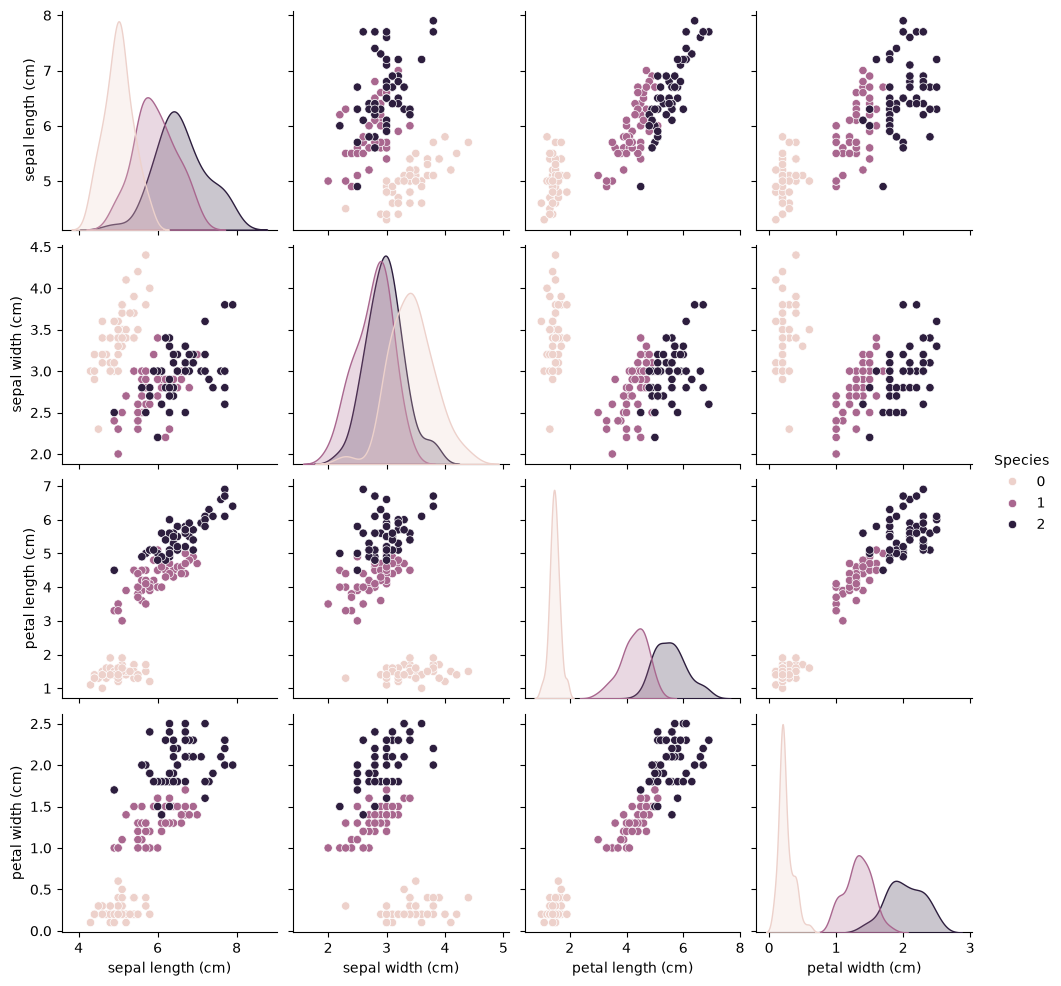

In [27]:
sns.pairplot(df, hue='Species') # สร้าง pairplot เพื่อดูความสัมพันธ์ระหว่างคุณลักษณะต่าง ๆ ของดอกไม้
plt.show() # แสดงกราฟที่สร้างขึ้น

### ตรวจสอบและทำความเสะอาดข้อมูล (Data Cleaning)

In [28]:
print(df.isnull().sum()) # ตรวจสอบว่ามีค่าที่หายไป (NaN) ในแต่ละคอลัมน์หรือไม่

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


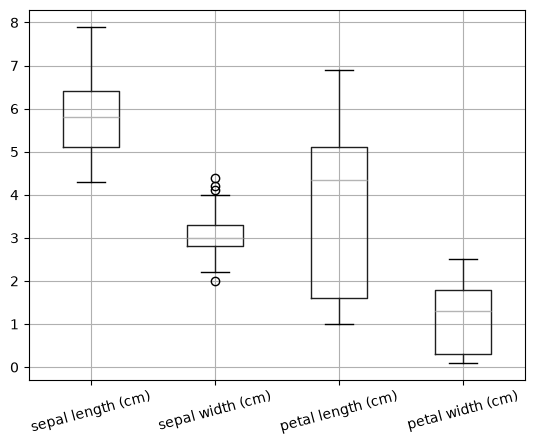

In [33]:
df.iloc[:, :4].boxplot() # สร้าง boxplot เพื่อดูการกระจายของข้อมูลในแต่ละคุณลักษณะ
plt.xticks(rotation=15); plt.show() # หมุนชื่อคอลัมน์เพื่อให้อ่านง่ายขึ้น

### แบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบ (Train-Test Split)

In [48]:
x = df.iloc[:, :4] # เลือกคุณลักษณะ (features) ทั้งหมด 4 คอลัมน์
y = df['Species'] # เลือกคอลัมน์ Species เป็นตัวแปร
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42,
     stratify=y) # แบ่งข้อมูลเป็นชุดฝึกและชุดทดสอบ โดยใช้ stratify เพื่อให้สัดส่วนของแต่ละชนิดของดอกไม้ในชุดฝึกและชุดทดสอบเหมือนกัน

print(f"Training set size: {x_train.shape[0]} samples") # แสดงจำนวนตัวอย่างในชุดฝึก
print(x_train.shape, x_test.shape) # แสดงขนาดของชุดฝึกและชุดทดสอบ
print(f"Test set size: {x_test.shape[0]} samples") # แสดงจำนวนตัวอย่างในชุดทดสอบ
print(y_train.shape, y_test.shape) # แสดงขนาดของตัวแปรเป้าหมายในชุดฝึกและชุดทดสอบ

Training set size: 120 samples
(120, 4) (30, 4)
Test set size: 30 samples
(120,) (30,)


In [44]:
scaler = StandardScaler() # สร้างตัวแปร scaler สำหรับปรับมาตรฐานของข้อมูล
x_train_scaled = scaler.fit_transform(x_train) # ปรับมาตรฐานของชุดฝึก
x_test_scaled = scaler.transform(x_test) # ปรับมาตรฐานของชุดทดสอบโดยใช้ค่าที่ได้จากชุดฝึก

### สร้างและฝึกโมเดล 3 แบบ (Logistic Regression, Decision Tree, Random Forest) และประเมินผล

In [45]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42)
}

for name, model in models.items():
    model.fit(x_train_scaled, y_train) # ฝึกโมเดลด้วยชุดฝึก
    acc_train = model.score(x_train_scaled, y_train) # คำนวณความแม่นยำของโมเดลในชุดฝึก
    acc_test = model.score(x_test_scaled, y_test) # คำนวณความแม่นยำของโมเดลในชุดทดสอบ
    print(f"{name} - Training Accuracy: {acc_train:.3f}, Test Accuracy: {acc_test:.3f}") # แสดงความแม่นยำของโมเดลในชุดฝึกและชุดทดสอบ

Decision Tree - Training Accuracy: 0.981, Test Accuracy: 0.978
K-Nearest Neighbors - Training Accuracy: 0.981, Test Accuracy: 0.911
Logistic Regression - Training Accuracy: 0.981, Test Accuracy: 0.911


### ประเมินผลด้วย 5-Fold Cross-Validation

In [46]:
X_s = StandardScaler().fit_transform(x) # ปรับมาตรฐานของข้อมูลทั้งหมด
for name, model in models.items():
    scores = cross_val_score(model, X_s, y, cv=5) # ประเมินผลด้วย 5-Fold Cross-Validation
    print(f"{name} - Cross-Validation Accuracy: {scores.mean():.3f} ± {scores.std():.3f}") # แสดงความแม่นยำเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของโมเดล

Decision Tree - Cross-Validation Accuracy: 0.973 ± 0.025
K-Nearest Neighbors - Cross-Validation Accuracy: 0.960 ± 0.025
Logistic Regression - Cross-Validation Accuracy: 0.960 ± 0.039


### สร้าง Confusion Matrix และ Classification Report สำหรับโมเดลที่ดีที่สุด

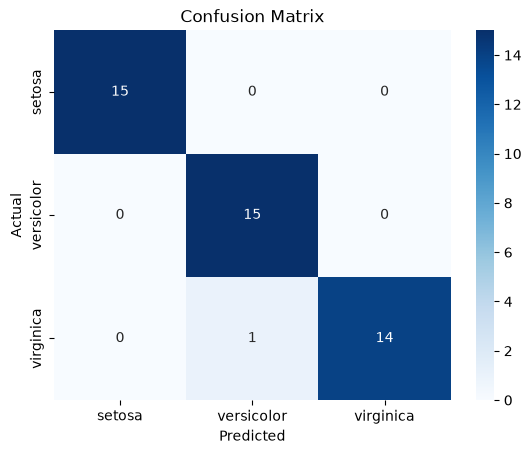

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [47]:
best = models['Decision Tree'] # เลือกโมเดลที่ดีที่สุด (Decision Tree)
y_pred = best.predict(x_test_scaled) # ทำนายผลด้วยชุดทดสอบ

cm = confusion_matrix(y_test, y_pred) # สร้าง Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names) # แสดง Confusion Matrix เป็น heatmap
plt.xlabel('Predicted') # กำหนดชื่อแกน x
plt.ylabel('Actual') # กำหนดชื่อแกน y
plt.title('Confusion Matrix') # กำหนดชื่อกราฟ
plt.show() # แสดงกราฟที่สร้างขึ้น

print(classification_report(y_test, y_pred, target_names=iris.target_names)) # แสดง Classification Report